<a href="https://colab.research.google.com/github/savarirangari-del/Sorry-gift/blob/main/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# if required:
#!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [33]:
import zipfile
import urllib.request
import os

url = "https://archive.ics.uci.edu/static/public/482/parking+birmingham.zip"

urllib.request.urlretrieve(url, "parking.zip")

with zipfile.ZipFile("parking.zip", "r") as zip_ref:
    zip_ref.extractall("parking_data")

print(os.listdir("parking_data"))

['dataset.csv']


In [34]:
df = pd.read_csv("parking_data/dataset.csv")

In [36]:
df = pd.read_csv("parking_data/dataset.csv")
print(df.head())
print(df.shape)
print(df.info())

  SystemCodeNumber  Capacity  Occupancy          LastUpdated
0      BHMBCCMKT01       577         61  2016-10-04 07:59:42
1      BHMBCCMKT01       577         64  2016-10-04 08:25:42
2      BHMBCCMKT01       577         80  2016-10-04 08:59:42
3      BHMBCCMKT01       577        107  2016-10-04 09:32:46
4      BHMBCCMKT01       577        150  2016-10-04 09:59:48
(35717, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35717 entries, 0 to 35716
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SystemCodeNumber  35717 non-null  object
 1   Capacity          35717 non-null  int64 
 2   Occupancy         35717 non-null  int64 
 3   LastUpdated       35717 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.1+ MB
None


In [14]:
#convert data/time
df["LastUpdated"]=pd.to_datetime(
    df["LastUpdated"],
    errors="coerce"
)

#Remove missing values
df=df.dropna()
#Remove duplicates()
df=df.sort_values(
    ["SystemCodeNumber","LastUpdated"]

).reset_index(drop=True)
print(df.isnull().sum())
print(df.shape)

SystemCodeNumber    0
Capacity            0
Occupancy           0
LastUpdated         0
dtype: int64
(35717, 4)


In [15]:
#Time features
df["Hour"]=df["LastUpdated"].dt.hour
df["Minute"]=df["LastUpdated"].dt.minute
df["DayOfWeek"] = df["LastUpdated"].dt.dayofweek
df["Month"]=df["LastUpdated"].dt.month

#Weekend
df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

# Occupancy rate
df["OccupancyRate"]=(
    df["Occupancy"]/df["Capacity"]
)*100

# Available parking spaces
df["AvailableSlots"]=(
    df["Capacity"]-df["Occupancy"]
)

In [16]:
# Previous occupancy
df["Lag1"] = df.groupby(
    "SystemCodeNumber"
)["Occupancy"].shift(1)

df["Lag2"] = df.groupby(
    "SystemCodeNumber"
)["Occupancy"].shift(2)

# Rolling average of previous observations
df["RollingMean3"] = df.groupby(
    "SystemCodeNumber"
)["Occupancy"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)

# Target = next occupancy
df["TargetOccupancy"] = df.groupby(
    "SystemCodeNumber"
)["Occupancy"].shift(-1)

In [17]:
df = df.dropna().reset_index(drop=True)

print(df.head())

  SystemCodeNumber  Capacity  Occupancy         LastUpdated  Hour  Minute  \
0      BHMBCCMKT01       577        107 2016-10-04 09:32:46     9      32   
1      BHMBCCMKT01       577        150 2016-10-04 09:59:48     9      59   
2      BHMBCCMKT01       577        177 2016-10-04 10:26:49    10      26   
3      BHMBCCMKT01       577        219 2016-10-04 10:59:48    10      59   
4      BHMBCCMKT01       577        247 2016-10-04 11:25:47    11      25   

   DayOfWeek  Month  IsWeekend  OccupancyRate  AvailableSlots   Lag1   Lag2  \
0          1     10          0      18.544194             470   80.0   64.0   
1          1     10          0      25.996534             427  107.0   80.0   
2          1     10          0      30.675910             400  150.0  107.0   
3          1     10          0      37.954939             358  177.0  150.0   
4          1     10          0      42.807626             330  219.0  177.0   

   RollingMean3  TargetOccupancy  
0     68.333333            

In [18]:
encoder = LabelEncoder()

df["ParkingID"] = encoder.fit_transform(
    df["SystemCodeNumber"]
)

In [19]:
features = [
    "Capacity",
    "Hour",
    "Minute",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "ParkingID",
    "Lag1",
    "Lag2",
    "RollingMean3"
]

X = df[features]
y = df["TargetOccupancy"]

In [20]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (28477, 10)
Testing: (7120, 10)


In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression
MAE: 185.9230774243755
RMSE: 319.5256943870142
R2 Score: 0.8507187184929392


In [22]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest
MAE: 168.17666192978197
RMSE: 299.30918019205035
R2 Score: 0.86901129312276


In [23]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

print(results)

               Model         MAE        RMSE  R2 Score
0  Linear Regression  185.923077  319.525694  0.850719
1      Random Forest  168.176662  299.309180  0.869011


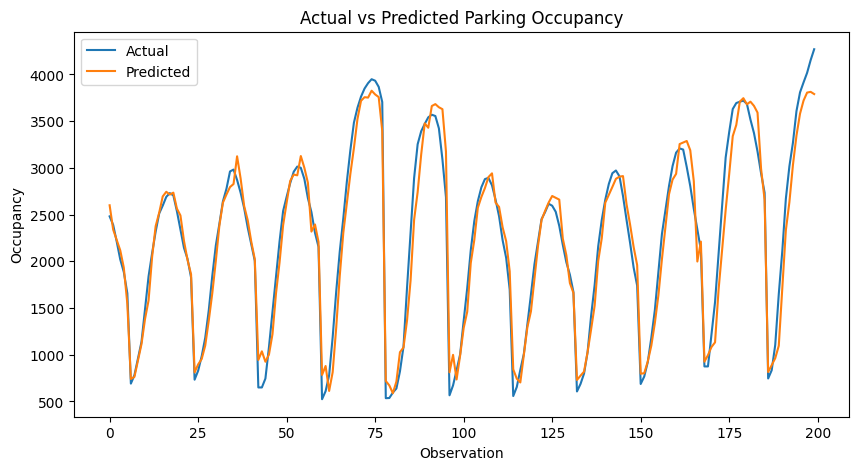

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    rf_pred[:200],
    label="Predicted"
)

plt.xlabel("Observation")
plt.ylabel("Occupancy")
plt.title("Actual vs Predicted Parking Occupancy")

plt.legend()
plt.show()

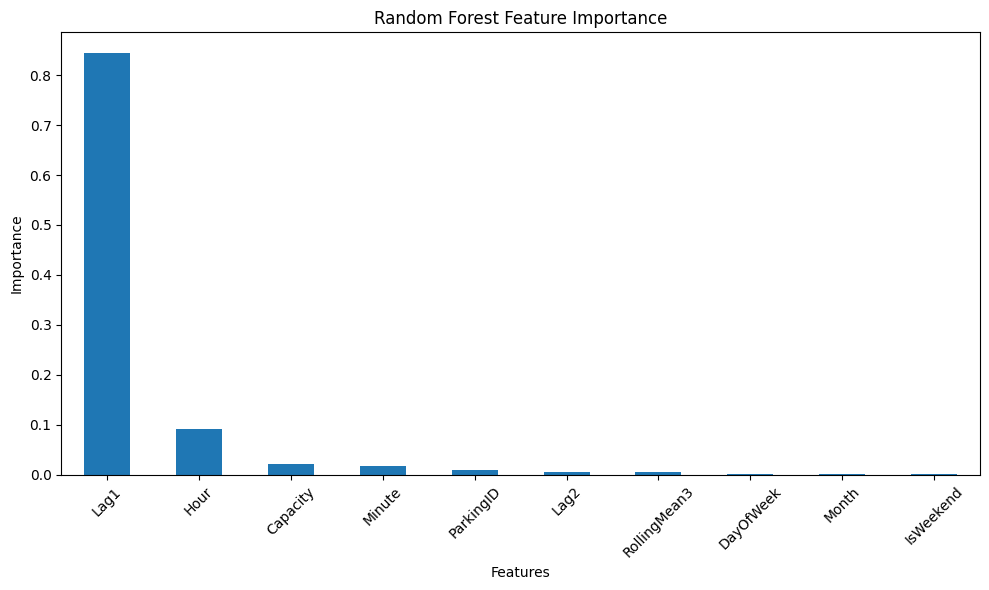

In [25]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [26]:
prediction_df = df.iloc[split_index:].copy()

prediction_df["PredictedOccupancy"] = rf_pred

prediction_df["PredictedAvailableSlots"] = (
    prediction_df["Capacity"]
    - prediction_df["PredictedOccupancy"]
)

# Avoid negative values
prediction_df["PredictedAvailableSlots"] = (
    prediction_df["PredictedAvailableSlots"]
    .clip(lower=0)
)

print(
    prediction_df[
        [
            "SystemCodeNumber",
            "Capacity",
            "PredictedOccupancy",
            "PredictedAvailableSlots"
        ]
    ].head(10)
)

      SystemCodeNumber  Capacity  PredictedOccupancy  PredictedAvailableSlots
28477  Others-CCCPS133      4675         2599.781370              2075.218630
28478  Others-CCCPS133      4675         2339.703444              2335.296556
28479  Others-CCCPS133      4675         2227.606328              2447.393672
28480  Others-CCCPS133      4675         2117.180202              2557.819798
28481  Others-CCCPS133      4675         1932.572054              2742.427946
28482  Others-CCCPS133      4675         1545.844375              3129.155625
28483  Others-CCCPS133      4675          740.720000              3934.280000
28484  Others-CCCPS133      4675          762.633333              3912.366667
28485  Others-CCCPS133      4675          936.423667              3738.576333
28486  Others-CCCPS133      4675         1114.388683              3560.611317


In [27]:
def parking_status(row):

    available = row["PredictedAvailableSlots"]
    capacity = row["Capacity"]

    percentage = (
        available / capacity
    ) * 100

    if percentage <= 5:
        return "FULL"

    elif percentage <= 20:
        return "LIMITED"

    else:
        return "AVAILABLE"


prediction_df["ParkingStatus"] = (
    prediction_df.apply(
        parking_status,
        axis=1
    )
)

print(
    prediction_df[
        [
            "SystemCodeNumber",
            "PredictedAvailableSlots",
            "ParkingStatus"
        ]
    ].head(20)
)

      SystemCodeNumber  PredictedAvailableSlots ParkingStatus
28477  Others-CCCPS133              2075.218630     AVAILABLE
28478  Others-CCCPS133              2335.296556     AVAILABLE
28479  Others-CCCPS133              2447.393672     AVAILABLE
28480  Others-CCCPS133              2557.819798     AVAILABLE
28481  Others-CCCPS133              2742.427946     AVAILABLE
28482  Others-CCCPS133              3129.155625     AVAILABLE
28483  Others-CCCPS133              3934.280000     AVAILABLE
28484  Others-CCCPS133              3912.366667     AVAILABLE
28485  Others-CCCPS133              3738.576333     AVAILABLE
28486  Others-CCCPS133              3560.611317     AVAILABLE
28487  Others-CCCPS133              3292.002456     AVAILABLE
28488  Others-CCCPS133              3092.751150     AVAILABLE
28489  Others-CCCPS133              2627.756535     AVAILABLE
28490  Others-CCCPS133              2299.018231     AVAILABLE
28491  Others-CCCPS133              2154.328582     AVAILABLE
28492  O

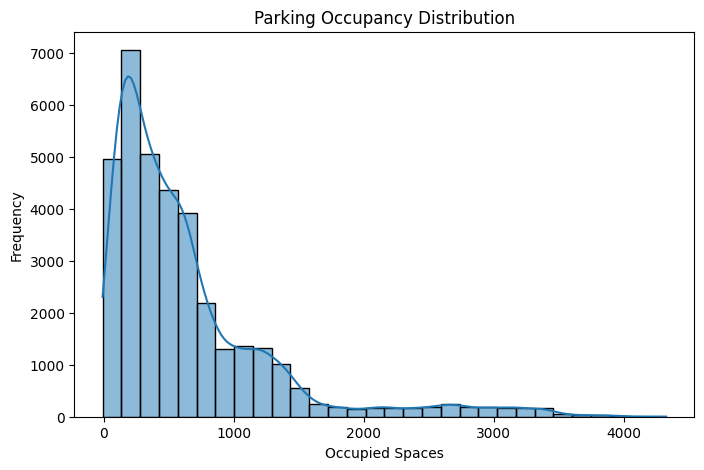

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Occupancy"],
    bins=30,
    kde=True
)

plt.title("Parking Occupancy Distribution")
plt.xlabel("Occupied Spaces")
plt.ylabel("Frequency")

plt.show()

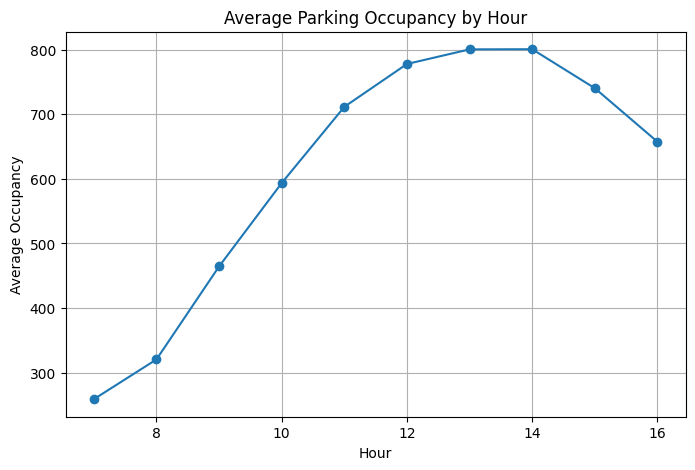

In [29]:
hour_avg = df.groupby("Hour")["Occupancy"].mean()

plt.figure(figsize=(8, 5))

hour_avg.plot(marker="o")

plt.title("Average Parking Occupancy by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Occupancy")

plt.grid()
plt.show()

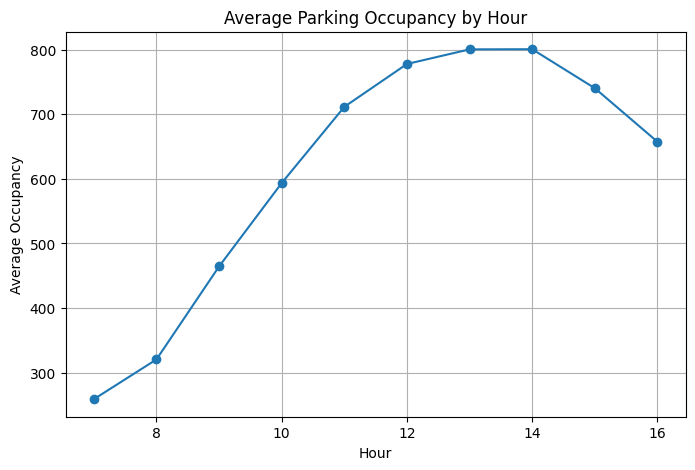

In [31]:
hour_avg = df.groupby("Hour")["Occupancy"].mean()

plt.figure(figsize=(8, 5))

hour_avg.plot(marker="o")

plt.title("Average Parking Occupancy by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Occupancy")

plt.grid()
plt.show()